In [1]:
import pandas as pd
import duckdb
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
query = "SELECT * FROM read_json_auto('../src/data/bostader.json')"
df = duckdb.query(query).to_df()
# Snabb överblick. Kvitton
df.head()

,id,typ,upplåtelseform,pris,avgift,rum,boyta,kvadratmeterpris,område,stad,adress,latitude,longitude,tillgänglig,created_at
0,1,hus,köpa,11411993,4177,4,108,105666,Bromma,Stockholm,Drottninggatan 28,59.33820,17.94255,True,2025-08-29
1,2,hus,köpa,6959222,2820,6,138,50429,Rosengård,Malmö,Skolvägen 104,55.58171,13.03274,True,2026-03-18
2,3,lägenhet,hyra,10345,0,3,75,0,Västra Hamnen,Malmö,Drottninggatan 90,55.60470,12.96912,True,2025-09-22
3,4,lägenhet,köpa,3484199,3983,3,69,50495,Linnéstaden,Göteborg,Kyrkogatan 33,57.69446,11.96088,True,2026-01-01
4,5,lägenhet,hyra,7077,0,2,42,0,Limhamn,Malmö,Hornsgatan 94,55.58295,12.93665,False,2025-09-14


In [ ]:
# Checka datatyper och antal icke-null (non-null) värden
# Se så att ingen data försvunnit
print(df.info())

# Om det finns dubletter baserat på 'id'-kolumnen, räkna dem
print(f"Antal dubletter: {df.duplicated(subset=['id']).sum()}")


<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   id                1000 non-null   int64         
 1   typ               1000 non-null   str           
 2   upplåtelseform    1000 non-null   str           
 3   pris              1000 non-null   int64         
 4   avgift            1000 non-null   int64         
 5   rum               1000 non-null   int64         
 6   boyta             1000 non-null   int64         
 7   kvadratmeterpris  1000 non-null   int64         
 8   område            1000 non-null   str           
 9   stad              1000 non-null   str           
 10  adress            1000 non-null   str           
 11  latitude          1000 non-null   float64       
 12  longitude         1000 non-null   float64       
 13  tillgänglig       1000 non-null   bool          
 14  created_at        1000 non-null   da

In [ ]:
# Grundläggande statistik för numeriska kolumner.. snitt, min, max osv.
display(df.describe())

,id,pris,avgift,rum,boyta,kvadratmeterpris,latitude,longitude,created_at
count,1000.000000,1.000000e+03,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000
mean,500.500000,4.372299e+06,2984.21300,3.489000,80.937000,53694.758000,57.528627,14.316432,2025-10-09 01:46:33.600000
min,1.000000,2.166000e+03,0.00000,1.000000,18.000000,0.000000,55.552060,11.890160,2025-04-09 00:00:00
25%,250.750000,1.013853e+06,1529.00000,2.000000,46.000000,33472.000000,55.602618,11.961630,2025-07-09 18:00:00
50%,500.500000,3.604906e+06,2839.50000,4.000000,80.000000,50628.500000,57.704910,12.975235,2025-10-08 00:00:00
75%,750.250000,6.621601e+06,4126.50000,5.000000,112.000000,76931.250000,59.312503,17.977963,2026-01-11 06:00:00
max,1000.000000,2.128271e+07,12538.00000,6.000000,168.000000,132518.000000,59.392160,18.172530,2026-04-09 00:00:00
std,288.819436,4.077370e+06,2401.94482,1.684255,41.233084,38192.532273,1.539000,2.660319,NaN


In [ ]:
# Flaggar eller logikfel
# Filtrera potentiella outliers baserat på kvadratmeterpris
outliers_query = """
    SELECT id, stad, område, boyta, pris, kvadratmeterpris
    FROM df
    WHERE kvadratmeterpris > 150000
       OR kvadratmeterpris < 10000
       OR boyta < 15
    ORDER BY kvadratmeterpris DESC
"""
outliers = duckdb.query(outliers_query).to_df()

print(f"Hittade {len(outliers)} potentiella outliers:")
display(outliers)

Hittade 219 potentiella outliers:


,id,stad,område,boyta,pris,kvadratmeterpris
0,3,Malmö,Västra Hamnen,75,10345,0
1,5,Malmö,Limhamn,42,7077,0
2,6,Stockholm,Nacka,38,5255,0
3,11,Stockholm,Hägersten,69,9242,0
4,17,Göteborg,Majorna,44,5722,0
...,...,...,...,...,...,...
214,990,Stockholm,Nacka,156,20562,0
215,993,Stockholm,Kungsholmen,25,3327,0
216,995,Stockholm,Kungsholmen,110,13237,0
217,996,Göteborg,Centrum,125,21248,0


<Figure size 1200x600 with 0 Axes>

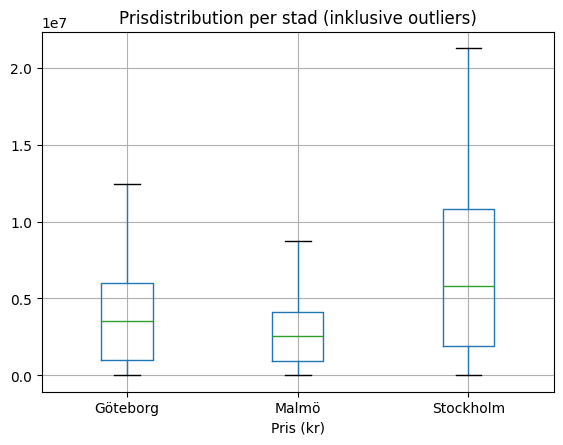

In [6]:
# Visualisera prisdistributionen per stad, inklusive outliers. Prisproblem osv.
plt.figure(figsize=(12, 6))
df.boxplot(column='pris', by='stad')
plt.title('Prisdistribution per stad (inklusive outliers)')
plt.suptitle('')
plt.xlabel('Pris (kr)')
plt.show()